In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

Line2D._us_dashSeq = property(lambda self: self._dash_pattern[1])
Line2D._us_dashOffset = property(lambda self: self._dash_pattern[0])
Legend._ncol = property(lambda self: self._ncols)

In [3]:
from utils.datasets.base_dataset import QUERY_TYPE
from pathlib import Path
import pandas as pd
from utils.helpers import to_pow_10


In [4]:
results_dir = Path("scratch") / "results"
figures_dir = Path("scratch") / "figures"
figures_dir.mkdir(exist_ok=True, parents=True)


def combine_dfs(pattern: str, base_dir: Path) -> pd.DataFrame:
    dfs = []
    for file in base_dir.glob(pattern):
        df = pd.read_csv(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


# stats_df = combine_dfs("bsbm_stats*.csv", results_dir)
# timings_df = combine_dfs("bsbm_timings*.csv", results_dir)
modes = {
    "bsbm": "BSBM",
    "dbpedia": "DBpedia",
}
mode = "dbpedia"
timings_df = pd.read_csv(results_dir / mode / f"{mode}_timings_all.csv")
stats_df = pd.read_csv(results_dir / mode / f"{mode}_stats_all.csv")

In [5]:
timings_df[(timings_df["query_type"] == "index") & (timings_df["engine"] == "Qlever") & (timings_df["difficulty"] == "hard")].sort_values("size")

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time
1,421770566,8,-1,0,Qlever,hard,index,6.645610,-1.0,-1.0,13.18
94,421770566,8,-1,93,Qlever,hard,index,3.740573,-1.0,-1.0,4.01
93,421770566,8,-1,92,Qlever,hard,index,3.745003,-1.0,-1.0,3.99
92,421770566,8,-1,91,Qlever,hard,index,3.737479,-1.0,-1.0,4.00
91,421770566,8,-1,90,Qlever,hard,index,3.737278,-1.0,-1.0,4.01
...,...,...,...,...,...,...,...,...,...,...,...
36,421770566,8,-1,35,Qlever,hard,index,3.688340,-1.0,-1.0,3.95
35,421770566,8,-1,34,Qlever,hard,index,3.690396,-1.0,-1.0,3.96
34,421770566,8,-1,33,Qlever,hard,index,3.668205,-1.0,-1.0,3.94
127,421770566,8,-1,126,Qlever,hard,index,3.723622,-1.0,-1.0,4.00


In [6]:
import numpy as np
timings_df = timings_df[timings_df["elapsed_time"].replace([np.inf, -np.inf], np.nan).notna()]

In [7]:
hard_timings = timings_df[timings_df["difficulty"] == "hard"]
hard_timings

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time
1,421770566,8,-1,0,Qlever,hard,index,6.645610,-1.0,-1.0,13.18
2,421770566,8,-1,1,Qlever,hard,index,4.213984,-1.0,-1.0,4.51
3,421770566,8,-1,2,Qlever,hard,index,4.413302,-1.0,-1.0,4.72
4,421770566,8,-1,3,Qlever,hard,index,4.202286,-1.0,-1.0,4.46
5,421770566,8,-1,4,Qlever,hard,index,3.829479,-1.0,-1.0,4.10
...,...,...,...,...,...,...,...,...,...,...,...
509,421770566,8,-1,123,Qlever (no Tensor Vocabulary),hard,index,5.457141,-1.0,-1.0,5.73
510,421770566,8,-1,124,Qlever (no Tensor Vocabulary),hard,index,5.478757,-1.0,-1.0,5.74
511,421770566,8,-1,125,Qlever (no Tensor Vocabulary),hard,index,5.468473,-1.0,-1.0,5.73
512,421770566,8,-1,126,Qlever (no Tensor Vocabulary),hard,index,5.484387,-1.0,-1.0,5.74


In [8]:
# timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['Qlever', 'Qlever (no Tensor Vocabulary)', 'Fuseki']
Length: 3, dtype: str

In [9]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [10]:
type_map = {
    "index": "Index",
    "embedded": "Embedded",
    "two_stage": "Two Stage",
}
timings_df["query_type"] = timings_df["query_type"].map(type_map, na_action="ignore")
stats_df["query_type"] = stats_df["query_type"].map(type_map, na_action="ignore")

In [11]:
timings_df

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time
1,421770566,8,-1,0,Qlever,hard,Index,6.645610,-1.000000,-1.0,13.18
2,421770566,8,-1,1,Qlever,hard,Index,4.213984,-1.000000,-1.0,4.51
3,421770566,8,-1,2,Qlever,hard,Index,4.413302,-1.000000,-1.0,4.72
4,421770566,8,-1,3,Qlever,hard,Index,4.202286,-1.000000,-1.0,4.46
5,421770566,8,-1,4,Qlever,hard,Index,3.829479,-1.000000,-1.0,4.10
...,...,...,...,...,...,...,...,...,...,...,...
894,421770566,8,-1,123,Fuseki,easy,Embedded,4.060352,0.805209,1.0,40.73
895,421770566,8,-1,124,Fuseki,easy,Embedded,4.052556,0.805209,1.0,39.54
896,421770566,8,-1,125,Fuseki,easy,Embedded,4.007313,0.805209,1.0,39.51
897,421770566,8,-1,126,Fuseki,easy,Embedded,4.065095,0.805209,1.0,39.87


In [17]:
engines = list(timings_df["engine"].unique())
engines.sort()
baseline_engine = engines[0]

from scipy.stats import ttest_ind


def siginificance_level(p_value: float) -> str:
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"


# calculate the median speedup vs the baseline engine for each difficulty + query type + engine + size
# + whether the speedup is statistically significant (using a t-test)
# the baseline engine
def calculate_speedup(
    df: pd.DataFrame, baseline_engine: str, baseline_type: str, relevant_measure: str
) -> pd.DataFrame:
    results = []
    chunks = df.groupby(
        ["difficulty", "query_type", "engine", "estimated_size", "size"]
    )
    super_chunks = df.groupby(
        [
            "difficulty",
            "query_type",
            "engine",
        ]
    )
    for i, group in chunks:
        super_group = super_chunks.get_group(
            (
                group["difficulty"].iloc[0],
                group["query_type"].iloc[0],
                group["engine"].iloc[0],
            )
        )
        if group.empty or (
            (group["query_type"] == baseline_type).all()
            and (group["engine"] == baseline_engine).all()
        ):
            continue
        baseline_group = df[
            (df["difficulty"] == group["difficulty"].iloc[0])
            & (df["query_type"] == baseline_type)
            & (df["engine"] == baseline_engine)
            & (df["estimated_size"] == group["estimated_size"].iloc[0])
            & (df["size"] == group["size"].iloc[0])
        ]
        if baseline_group.empty:
            continue
        measure_group = group[relevant_measure]
        measure_baseline_group = baseline_group[relevant_measure]
        t_stat, p_value = ttest_ind(
            measure_group, measure_baseline_group, equal_var=False, alternative="less"
        )
        adjusted_alpha = 0.01 / len(chunks)  # Bonferroni correction
        speedup = measure_baseline_group.mean() / measure_group.mean()
        result = {
            "difficulty": group["difficulty"].iloc[0],
            "query_type": group["query_type"].iloc[0],
            "engine": group["engine"].iloc[0],
            "estimated_size": group["estimated_size"].iloc[0],
            "size": group["size"].iloc[0],
            "speedup": speedup,
            "p_value": p_value,
            "significance_level": siginificance_level(p_value),
            "significant": p_value < adjusted_alpha,
        }
        if mode == "dbpedia":
            del result["estimated_size"]
        results.append(result)

    df = pd.DataFrame(results)
    # index by difficulty, query type, engine, size
    # df.set_index(["difficulty", "query_type", "engine", "size"], inplace=True)
    return df


speedup = calculate_speedup(timings_df, baseline_engine, "Embedded", "elapsed_time")
from utils.helpers import pretty_print_counts

pretty_print_counts(
    speedup,
    figures_dir / f"{mode}_speedup.tex",
    column_mapping={
        "difficulty": "Difficulty",
        "query_type": "Query Type",
        "estimated_size": "$m$",
        "engine": "Engine",
        "speedup": "Speedup",
        "p_value": "$p$-value",
        # "significance_level": "Significance",
        # "significant": "Significant",
    },
    format_cols=["estimated_size", "speedup", "p_value"],
    to_int_cols=["estimated_size"],
    index_cols=["difficulty", "query_type", "engine", "estimated_size"],
    label_xtra=f"{mode}_speedup",
    caption=f"Speedup of our implementation vs {baseline_engine} on the Embedded queries for our extended {modes[mode]} sets",
)

['speedup', 'p_value'] ['difficulty', 'query_type', 'engine']
Indexing by ['Difficulty', 'Query Type', 'Engine']


Speedup     $p$-value
Difficulty Query Type Engine                                                
easy       Embedded   Qlever                         21.103647  1.195142e-46
                      Qlever (no Tensor Vocabulary)   1.442412  1.555036e-11
           Index      Qlever                          2.035278  4.085181e-23
                      Qlever (no Tensor Vocabulary)   0.895963  9.965783e-01

In [17]:
speedup

,difficulty,query_type,engine,size,speedup,p_value,significance_level,significant
0,easy,Embedded,Qlever,421770566,21.103647,1.195142e-46,***,True
1,easy,Embedded,Qlever (no Tensor Vocabulary),421770566,1.442412,1.555036e-11,***,True
2,easy,Index,Qlever,421770566,2.035278,4.085181e-23,***,True
3,easy,Index,Qlever (no Tensor Vocabulary),421770566,0.895963,9.965783e-01,ns,False


In [35]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [36]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'Fuseki + RDFTensor': 'C0',
 'Qlever': 'C1',
 'Qlever (no Tensor Vocabulary)': 'C2'}

In [37]:
median_timings

,estimated_size,engine,difficulty,query_type,elapsed_time
0,1,Fuseki + RDFTensor,easy,Embedded,0.177935
1,1,Fuseki + RDFTensor,easy,Two Stage,2.485894
2,1,Fuseki + RDFTensor,hard,Embedded,0.029549
3,1,Qlever,easy,Embedded,0.007422
4,1,Qlever,easy,Index,0.005377
5,1,Qlever,easy,Two Stage,0.955966
6,1,Qlever,hard,Embedded,0.006476
7,1,Qlever,hard,Index,0.006672
8,1,Qlever (no Tensor Vocabulary),easy,Embedded,0.007347
9,1,Qlever (no Tensor Vocabulary),easy,Index,0.007328


In [38]:
import matplotlib.pyplot as plt
import tikzplotlib
import seaborn as sns
import numpy as np

plt.rc("text", usetex=True)
plt.rc("text.latex", preamble="""\\usepackage{amsmath}""")
plt.style.use("fivethirtyeight")
# set background color to white of the figure and axes
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

palette = sns.color_palette('colorblind').as_hex()
def adjust_lightness(color, amount=1.1):
    import matplotlib.colors as mc
    import colorsys

    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], np.maximum(0, np.minimum(1, amount * c[1])), c[2])

plt.rcParams.update({'errorbar.capsize': 2})

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Extrapolated sizes for Fuseki + RDFTensor - embedded: [3577077, 35177974] [12.278839841485023, 313.17610224470803] existing points [2418, 5595, 42417, 383751, 3577077] [0.17793541774153704, 0.033447343856096254, 0.12704150006175036, 1.172828160226345, 12.278839841485023]
Extrapolated sizes for Qlever (no Tensor Vocabulary) - embedded: [3577077, 35177974] [9.48384329304099, 215.4541405908902] existing points [2418, 5595, 42417, 383751, 3577077] [0.007346853613853449, 0.01746306568384165, 0.10766725242137905, 0.8873206041753292, 9.48384329304099]


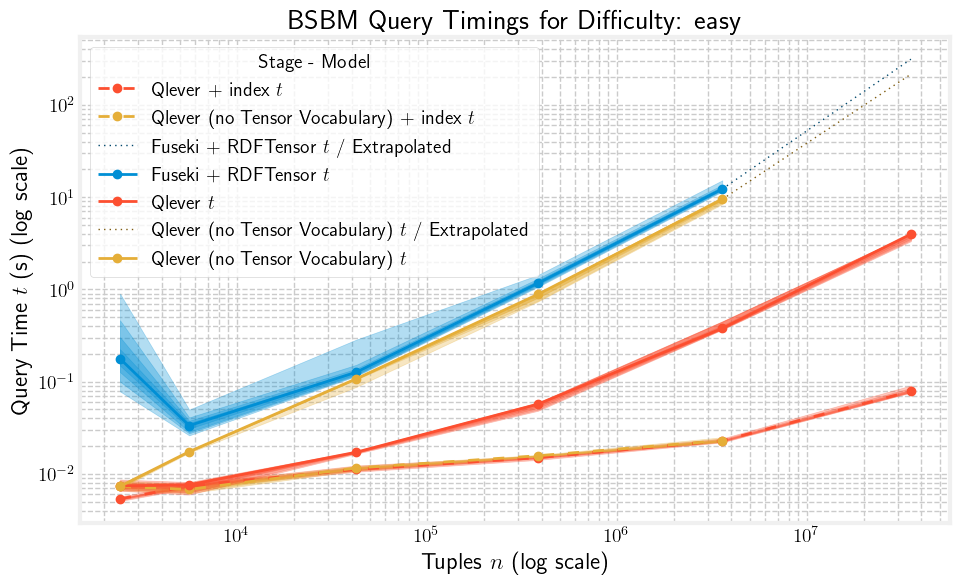

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Extrapolated sizes for Qlever - index: [3577077, 35177974] [14.909817278385162, 461.38285592858995] existing points [2418, 5595, 42417, 383751, 3577077] [0.00667239353060715, 0.0109833329916, 0.07104953005909914, 1.2376011908054352, 14.909817278385162]
Extrapolated sizes for Qlever (no Tensor Vocabulary) - index: [3577077, 35177974] [29.600356124341488, 1364.5235192566186] existing points [2418, 5595, 42417, 383751, 3577077] [0.01047939434647555, 0.01976089552044865, 0.1363573037087917, 1.9757331274449825, 29.600356124341488]
Extrapolated sizes for Fuseki + RDFTensor - embedded: [5595, 42417, 383751, 3577077, 35177974] [2.3908282220363617, 382.94577215131756, 34863.369028679714, 3064138.3932400197, 296708195.55900913] existing points [2418, 5595] [0.0295486152172088, 2.3908282220363617]
Extrapolated sizes for Qlever - embedded: [42417, 383751, 3577077, 35177974] [22.310562424

/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


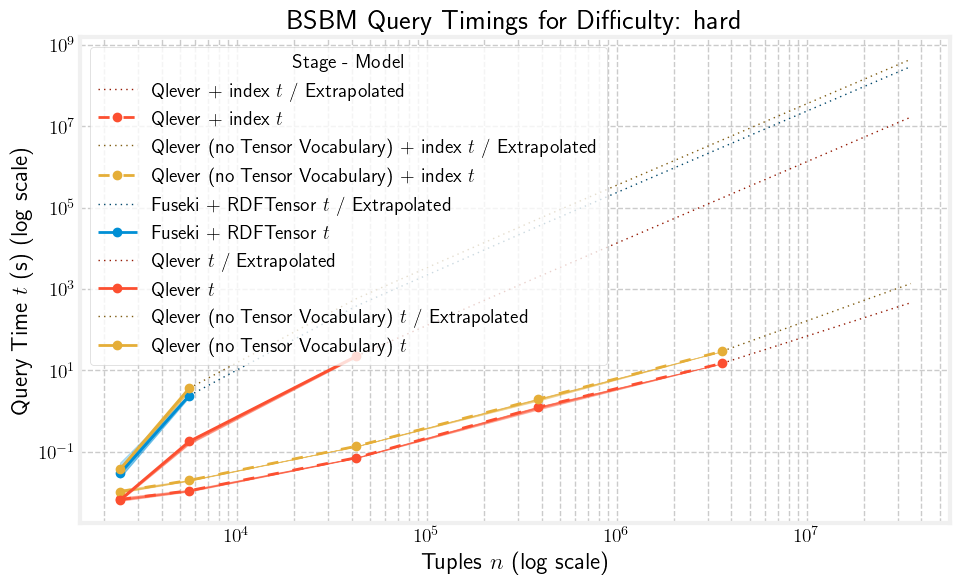

Quantiles [0.05, 0.95]
Extrapolated sizes for Fuseki + RDFTensor - embedded: [3577077, 35177974] [12.278839841485023, 313.17610224470803] existing points [2418, 5595, 42417, 383751, 3577077] [0.17793541774153704, 0.033447343856096254, 0.12704150006175036, 1.172828160226345, 12.278839841485023]
Extrapolated sizes for Qlever (no Tensor Vocabulary) - embedded: [3577077, 35177974] [9.48384329304099, 215.4541405908902] existing points [2418, 5595, 42417, 383751, 3577077] [0.007346853613853449, 0.01746306568384165, 0.10766725242137905, 0.8873206041753292, 9.48384329304099]


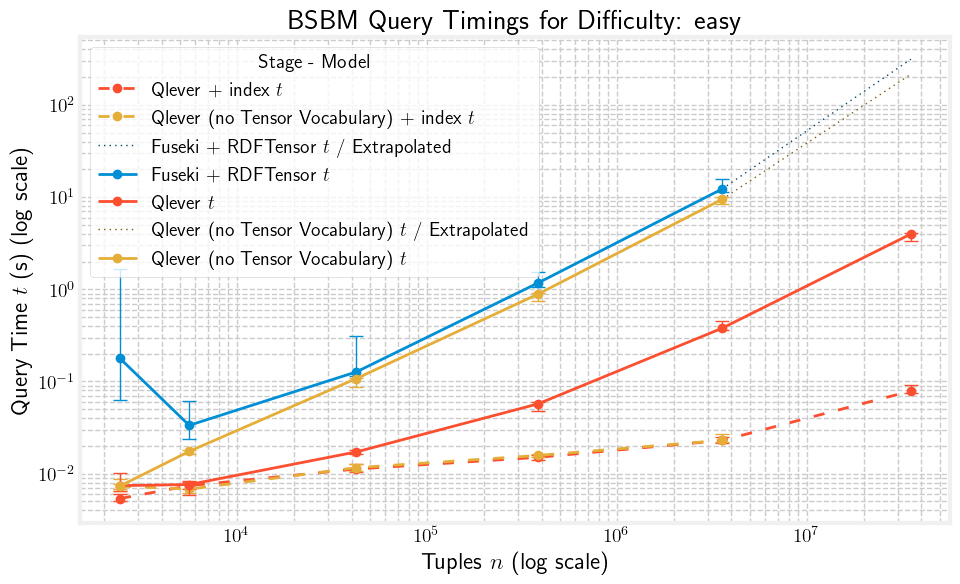

Quantiles [0.05, 0.95]
Extrapolated sizes for Qlever - index: [3577077, 35177974] [14.909817278385162, 461.38285592858995] existing points [2418, 5595, 42417, 383751, 3577077] [0.00667239353060715, 0.0109833329916, 0.07104953005909914, 1.2376011908054352, 14.909817278385162]
Extrapolated sizes for Qlever (no Tensor Vocabulary) - index: [3577077, 35177974] [29.600356124341488, 1364.5235192566186] existing points [2418, 5595, 42417, 383751, 3577077] [0.01047939434647555, 0.01976089552044865, 0.1363573037087917, 1.9757331274449825, 29.600356124341488]
Extrapolated sizes for Fuseki + RDFTensor - embedded: [5595, 42417, 383751, 3577077, 35177974] [2.3908282220363617, 382.94577215131756, 34863.369028679714, 3064138.3932400197, 296708195.55900913] existing points [2418, 5595] [0.0295486152172088, 2.3908282220363617]
Extrapolated sizes for Qlever - embedded: [42417, 383751, 3577077, 35177974] [22.310562424361706, 1991.8260633152588, 174703.7940502927, 16913295.53753358] existing points [2418, 

/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


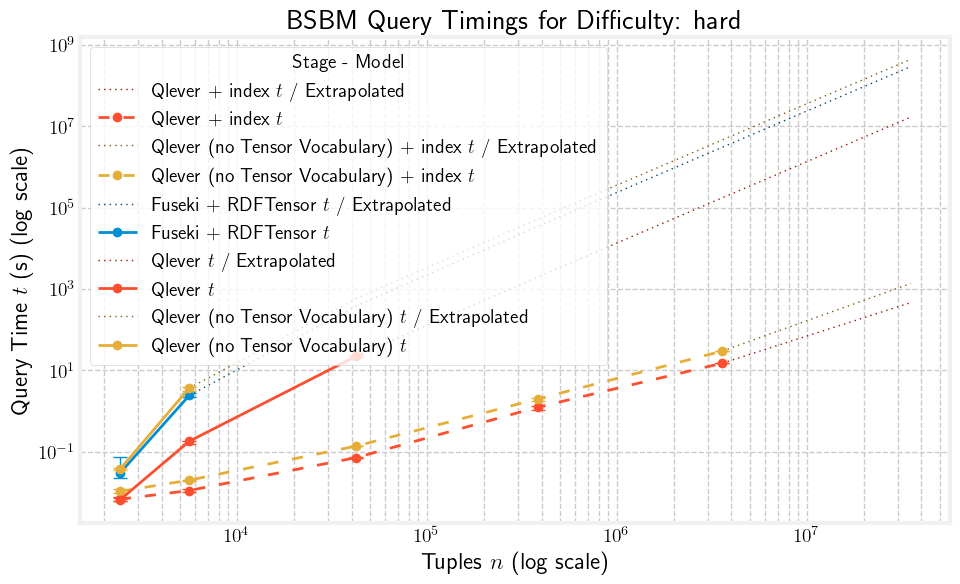

In [39]:
from numpy.polynomial import Polynomial, Hermite, Chebyshev


def extrapolate_missing_sizes(
    df,
    possible_sizes,
    relevant_measure,
    fns=[
        lambda x: x**2,
        lambda x: x,
        lambda x : np.sqrt(x),
        lambda x: np.ones_like(x),
    ],
):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]

    missing_sizes = [s for s in possible_sizes if s not in df_filtered["size"].unique()]
    missing_sizes.sort()
    # missing_sizes = missing_sizes[:-1]
    missing_sizes = np.array(missing_sizes)
    if df_filtered.empty or len(missing_sizes) == 0:
        return None
    x_data = df_filtered["size"].values
    y_data = df_filtered[relevant_measure].values

    poly = Polynomial.fit(x_data, y_data, deg=2)
    y_pred = poly(missing_sizes)
    # if (y_pred <= 0).any():
    # Phi = np.column_stack([fn(x_data) for fn in fns])
    # # calculate the coefficients using least squares with regularization to prevent overfitting
    # lbd = 0.0
    # coefs = (
    #     np.linalg.inv(Phi.T @ Phi / x_data.shape[0] + lbd * np.eye(Phi.shape[1]))
    #     @ Phi.T
    #     @ y_data
    # )
    # print("Coefficients for extrapolation:", coefs)
    # y_pred = np.dot(coefs, [fn(missing_sizes) for fn in fns])
    extrapolated_df = pd.DataFrame(
        {
            "size": missing_sizes,
            relevant_measure: y_pred,
        }
    )
    if extrapolated_df.empty:
        return None
    # add last known size and measure to the extrapolated df to make the plot look better
    last_known_size = df_filtered["size"].max()
    last_known_measure = df_filtered[df_filtered["size"] == last_known_size][
        relevant_measure
    ].values[0]
    extrapolated_df = pd.concat(
        [
            pd.DataFrame(
                {"size": [last_known_size], relevant_measure: [last_known_measure]}
            ),
            extrapolated_df,
        ],
        ignore_index=True,
    )
    return extrapolated_df


def fit_to_fn(df, relevant_measure, fn: (lambda x: x)):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]
    if df_filtered.empty:
        return None
    x_data = df_filtered["size"].values
    # y_data = df_filtered[relevant_measure].values
    const = x_data[0] if x_data[0] > 0 else 1
    x_data_fn = fn(x_data / const) * const
    Phi = np.vstack([x_data_fn, np.ones(len(x_data_fn))])
    coeffs = np.linalg.lstsq(Phi, df_filtered[relevant_measure].values, rcond=None)[0]
    a, b = coeffs
    y_fitted = a * x_data_fn + b
    fitted_df = pd.DataFrame(
        {
            "size": x_data,
            relevant_measure: y_fitted,
        }
    )
    return fitted_df


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(
    ax,
    df,
    engine,
    difficulty,
    relevant_measure="elapsed_time",
    extrapolate=True,
    fill_pdf=True,
    pdf_steps=5,
    fit_fn=None,
):
    groupings = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = (
        [0.05, 0.95] if not fill_pdf else np.linspace(0, 1, 1 + pdf_steps * 2).tolist()
    )
    print("Quantiles", quantiles)
    mean_timings = groupings.mean().reset_index()
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    possible_sizes = sorted(df["size"].unique())
    all_extended_dfs = []
    for query_type in [QUERY_TYPE.INDEX, QUERY_TYPE.EMBEDDED]:
        for engine in mean_timings["engine"].unique():
            engine_mean = mean_timings[
                (mean_timings["query_type"] == type_map[query_type.value])
                & (mean_timings["difficulty"] == difficulty)
                & (mean_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == type_map[query_type.value])
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            engine_median = median_timings[
                (median_timings["query_type"] == type_map[query_type.value])
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            if engine_mean.empty or engine_quantiles.empty:
                continue

            extrapolated_df = None
            engine_median = engine_median[engine_median[relevant_measure].notna()]
            # extrapolate missing sizes by linear regression

            if extrapolate:
                extrapolated_df = extrapolate_missing_sizes(
                    engine_median, possible_sizes, relevant_measure
                )

            # index are dashed, embedded are solid
            linestyle = (0, (4, 5)) if query_type == QUERY_TYPE.INDEX else "-"
            lbl = f"{engine}"
            if query_type.value != QUERY_TYPE.EMBEDDED.value:
                lbl += f" + {query_type.value}"
            lbl += " $t$"
            if (
                extrapolated_df is not None
                and not extrapolated_df.empty
                and extrapolated_df.shape
                and (extrapolated_df[relevant_measure] > 0).all()
            ):
                all_extended_dfs.append(extrapolated_df)
                print(
                    f"Extrapolated sizes for {engine} - {query_type.value}: {extrapolated_df['size'].tolist()}",
                    extrapolated_df[relevant_measure].tolist(),
                    "existing points",
                    engine_median["size"].tolist(),
                    engine_median[relevant_measure].tolist(),
                )
                ax.plot(
                    extrapolated_df["size"],
                    extrapolated_df[relevant_measure],
                    linestyle=(0, (1, 3)),
                    label=f"{lbl} / Extrapolated",
                    color=adjust_lightness(colors[engine], 0.5),
                    linewidth=1,
                )
            if fit_fn is not None and fit_fn is not False:
                fit_fn = (
                    fit_fn if isinstance(fit_fn, type(lambda: None)) else lambda x: x
                )
                fitted_df = fit_to_fn(
                    engine_median,
                    relevant_measure,
                    fn=fit_fn,
                )
                if fitted_df is not None and not fitted_df.empty:
                    ax.plot(
                        fitted_df["size"],
                        fitted_df[relevant_measure],
                        linestyle=(0, (5, 10)),
                        label=f"{lbl} / Fit",
                        color=adjust_lightness(colors[engine], 0.8),
                        linewidth=1,
                    )
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                "o",
                linestyle=linestyle,
                label=lbl,
                color=colors[engine],
                linewidth=2,
            )
            if fill_pdf:
                if engine_median["size"].shape[0] > 1:
                    for i in range(0, pdf_steps - 1):
                        ax.fill_between(
                            engine_quantiles["size"],
                            engine_quantiles[quantiles[pdf_steps - 1 - i]],
                            engine_quantiles[quantiles[pdf_steps + 1 + i]],
                            color=colors[engine],
                            alpha=0.3,
                        )
            else:
                ax.errorbar(
                    engine_median["size"],
                    engine_median[relevant_measure],
                    yerr=[
                        engine_median[relevant_measure] - engine_quantiles[0.05],
                        engine_quantiles[0.95] - engine_median[relevant_measure],
                    ],
                    barsabove=True,
                    capsize=5,
                    linewidth=1,
                    fmt="none",
                    # label=f"5\%-95\% quantiles ({engine})",
                    color=colors[engine],
                )
    return pd.concat(all_extended_dfs) if all_extended_dfs else None


overview_dir = figures_dir / "overview"
overview_dir.mkdir(exist_ok=True, parents=True)


def calc_extra_ticks(series: pd.Series, tweens=[2, 3, 4, 5, 6, 7, 8, 9]):
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    min_size = int(np.log10(series.min())) - 1
    max_size = int(np.log10(series.max())) + 2

    extra_ticks = [10**i * tween for i in range(min_size, max_size) for tween in tweens]
    return extra_ticks


extra_y_ticks = calc_extra_ticks(timings_df["elapsed_time"])
extra_x_ticks = calc_extra_ticks(timings_df["size"])
for fill_pdf in [True, False]:
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # ax = axes[i] if len(difficulties) > 1 else axes
        # set the suxbtitle to the difficulty

        extended_dfs = plot_timings(
            ax,
            timings_df,
            engines,
            difficulty,
            fill_pdf=fill_pdf,
            fit_fn=False,
        )
        complete_plotted_df = (
            pd.concat([timings_df, extended_dfs])
            if extended_dfs is not None
            else timings_df
        )
        extra_y_ticks_plt = calc_extra_ticks(complete_plotted_df["elapsed_time"])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Tuples $n$ (log scale)")
        ax.set_ylabel("Query Time $t$ (s) (log scale)")
        ax.set_title(f"{mode.upper()} Query Timings for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        fill_str = "_filled" if fill_pdf else ""
        tikzplotlib.save(
            overview_dir / f"{mode}_timings_{difficulty}{fill_str}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                        legend pos=south west, 
                        legend style={
                    font=\\small},
                        legend columns=2, 
                        extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                        extra y ticks={"""
                + ",".join(map(str, extra_y_ticks_plt))
                + """},
                        extra x tick labels={ },
                        extra y tick labels={ },
                        extra tick style={
                            tick style={draw=none},
                            major grid style={dashed,red},
                            grid=major,
                        },
                    }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            overview_dir / f"{mode}_timings_{difficulty}_legend{fill_str}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                        legend pos=south west, 
                        legend style={
                    font=\\small},
                        legend columns=5, 
                        extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                        extra y ticks={"""
                + ",".join(map(str, extra_y_ticks_plt))
                + """},
                        extra x tick labels={ },
                        extra y tick labels={ },
                        extra tick style={
                            tick style={draw=none},
                            major grid style={dashed,red},
                            grid=major,
                        },
                    }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        plt.savefig(overview_dir / f"{mode}_timings_{difficulty}{fill_str}.png")
        plt.show()

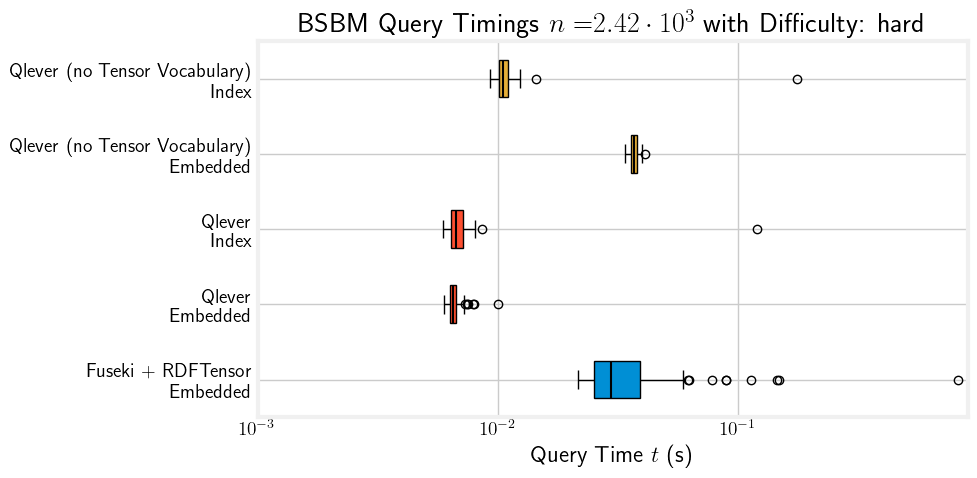

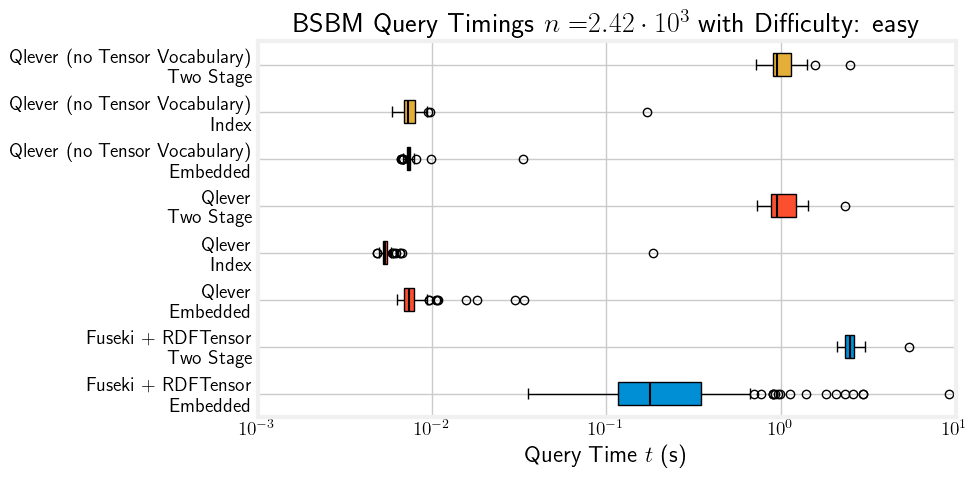

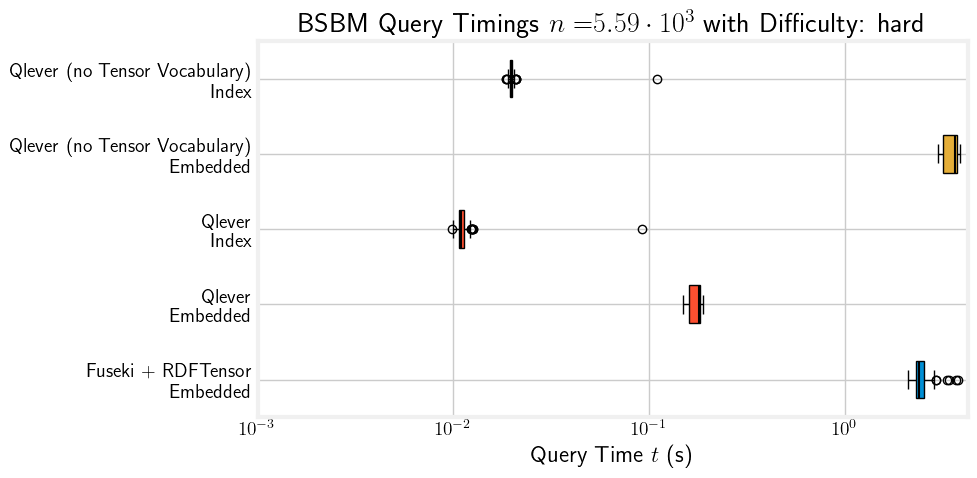

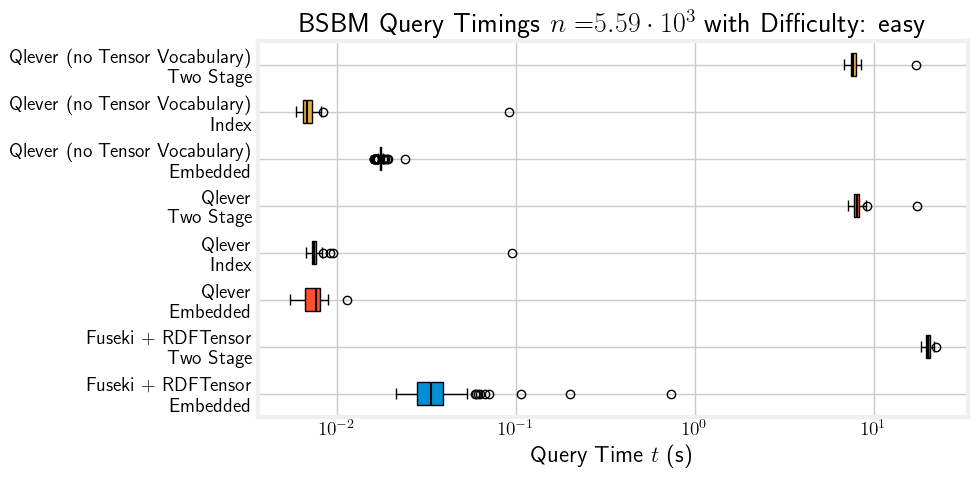

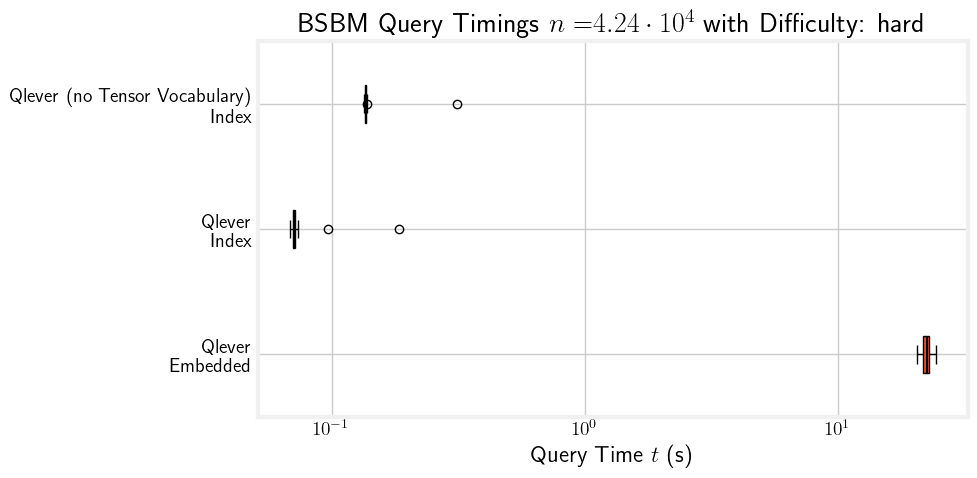

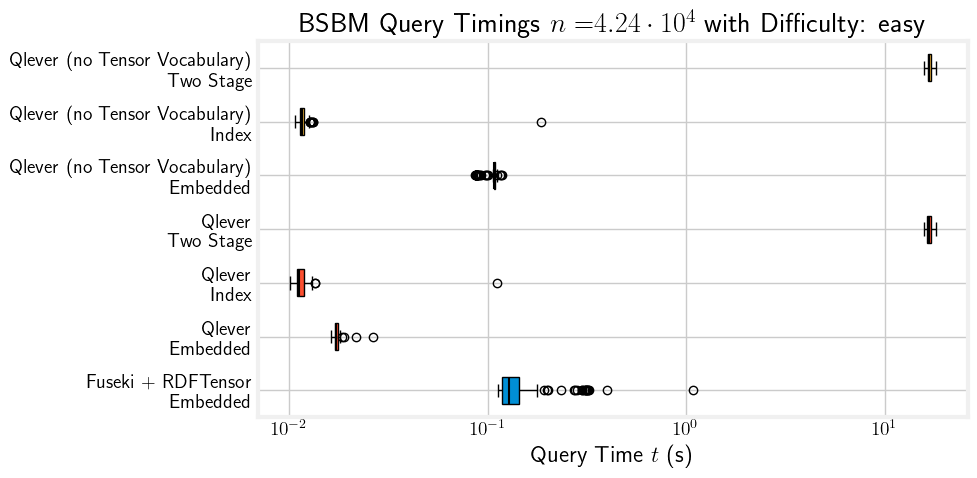

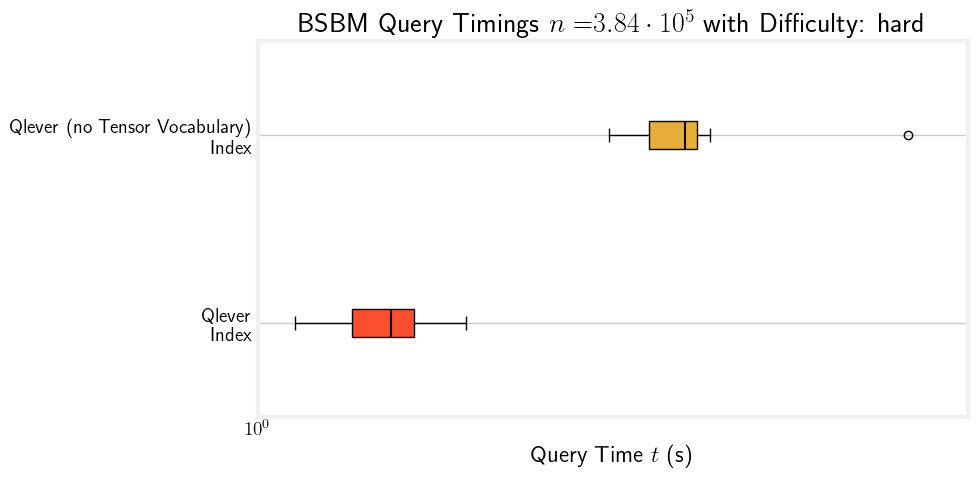

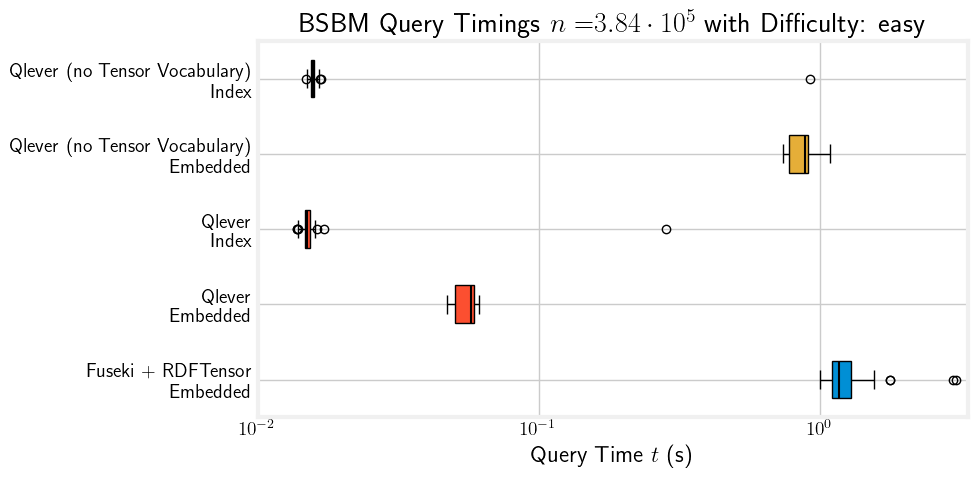

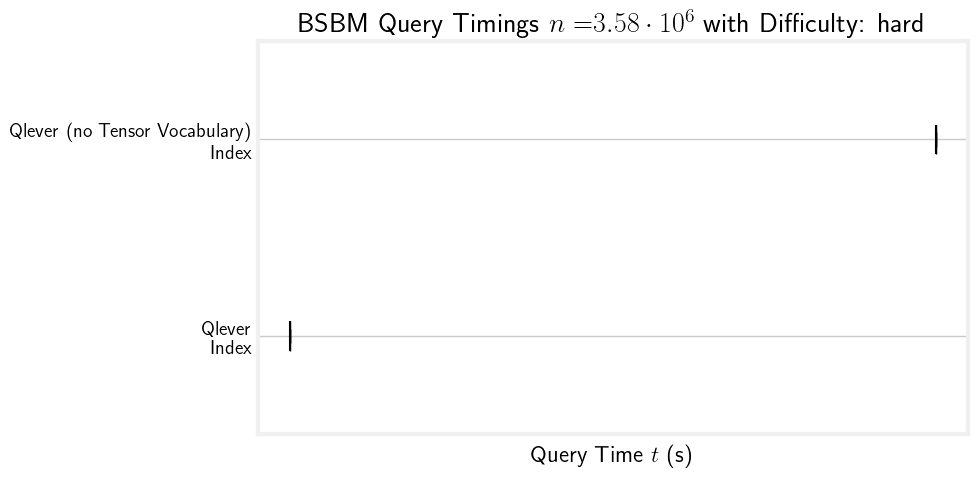

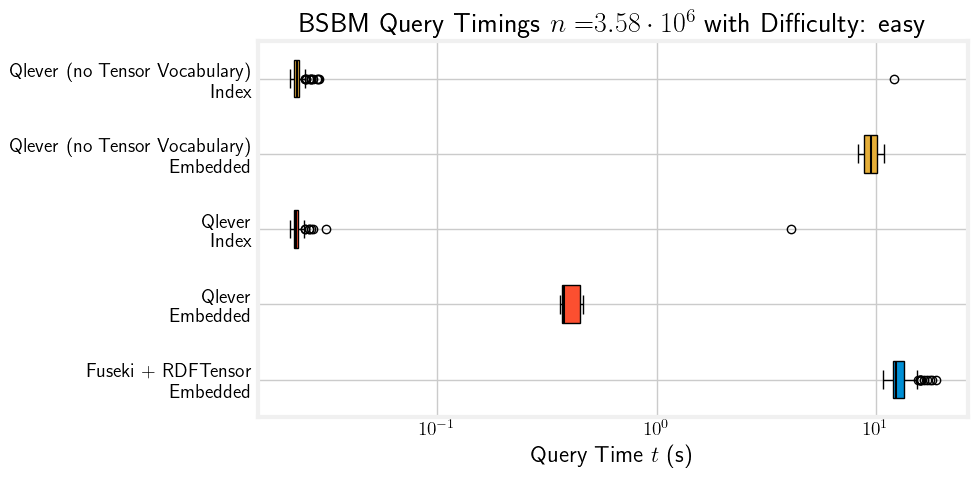

No measures for size 35177974 and difficulty hard


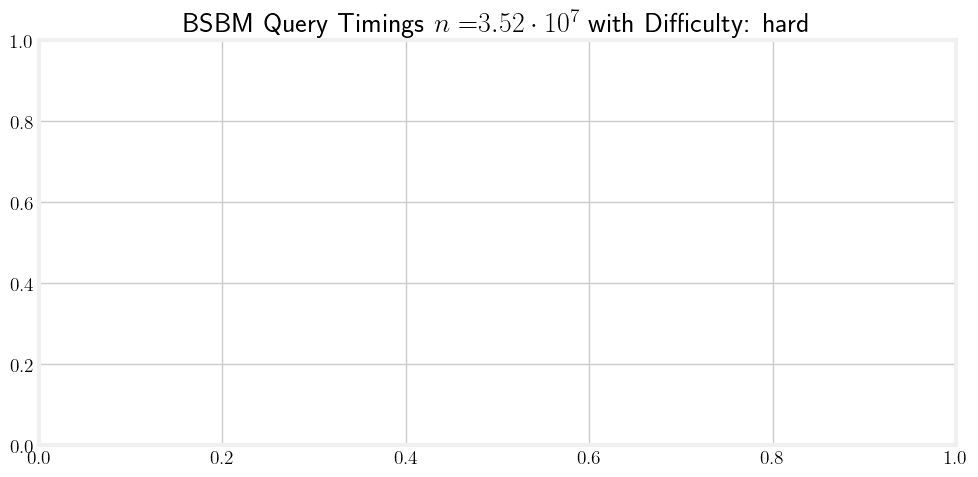

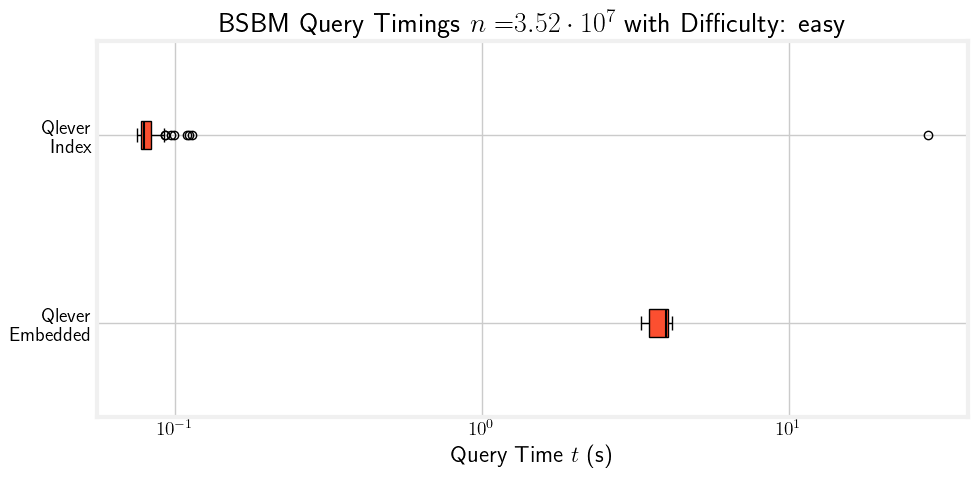

In [40]:
def plot_boxplot(
    ax: plt.Axes,
    df: pd.DataFrame,
    size: int,
    difficulty: str,
    relevant_measure: str = "elapsed_time",
):
    ax.set_title(
        f" {modes[mode]} Query Timings $n=${to_pow_10(size)} with Difficulty: {difficulty}"
    )
    size_df = df[df["size"] == size]
    engine_types = size_df.apply(
        lambda row: (row["engine"], row["query_type"]), axis=1
    ).unique()

    tick_labels = list(engine_types)
    measures: list[pd.Series] = [
        size_df[
            (size_df["difficulty"] == difficulty)
            & (size_df["engine"] == engine)
            & (size_df["query_type"] == query_type)
        ][relevant_measure]
        for engine, query_type in tick_labels
    ]
    # filter infinite and nan values from measures and corresponding tick labels
    measures_f = [
        measures[i].replace([np.inf, -np.inf], np.nan).dropna()
        for i in range(len(measures))
    ]
    measures = [
        measures_f[i] for i in range(len(measures_f)) if not measures_f[i].shape[0] == 0
    ]
    tick_labels = [
        tick_labels[i]
        for i in range(len(tick_labels))
        if not measures_f[i].shape[0] == 0
    ]
    if len(measures) == 0:
        print(f"No measures for size {size} and difficulty {difficulty}")
        return
    all_measures = pd.concat(measures)
    bplot = ax.boxplot(
        measures,
        tick_labels=[f"{engine}\n{query_type}" for engine, query_type in tick_labels],
        vert=False,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5},
        # showfliers=False,
    )
    ax.set_xlabel("Query Time $t$ (s)")
    ax.set_xscale("log")
    ax.set_xticklabels([], minor=True)
    # fill with colors
    for patch, (engine, query_type) in zip(bplot["boxes"], tick_labels):
        patch.set_facecolor(
            adjust_lightness(colors[engine])
            if query_type == QUERY_TYPE.INDEX.value
            else colors[engine]
        )
    if abs(all_measures.min() - all_measures.max()) < 10:
        min_power = int(np.floor(np.log10(all_measures.min())))
        max_power = int(np.ceil(np.log10(all_measures.max())))
        ax.set_xlim(left=10**min_power, right=all_measures.max()*1.1)


boxplots_dir = figures_dir / "boxplots"
boxplots_dir.mkdir(exist_ok=True, parents=True)
for est_size in timings_df["estimated_size"].unique():
    for difficulty in difficulties[::-1]:
        fig, ax = plt.subplots(1, figsize=(10, 5))
        eval_size = timings_df[timings_df["estimated_size"] == est_size][
            "size"
        ].unique()[0]
        plot_boxplot(ax, timings_df, eval_size, difficulty)
        plt.tight_layout()
        tikzplotlib.save(
            boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=2, 
                    extra x ticks={"""
                + ",".join(map(str, extra_y_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="0.7\\textwidth",
            axis_width="1.25\\textwidth",
        )
        plt.savefig(boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.png")
        plt.show()

In [41]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-04-22 15:51:57.775627,0.0,328978432,-1,-1,1,2418,3,easy,Embedded,1,Fuseki + RDFTensor
1,2026-04-22 15:51:58.540870,525.4,331927552,-1,-1,1,2418,3,easy,Embedded,1,Fuseki + RDFTensor
2,2026-04-22 15:51:59.034630,390.5,333697024,-1,-1,1,2418,3,easy,Embedded,1,Fuseki + RDFTensor
3,2026-04-22 15:51:59.628854,403.9,334286848,-1,-1,1,2418,3,easy,Embedded,1,Fuseki + RDFTensor
4,2026-04-22 15:52:00.121498,329.0,336646144,-1,-1,1,2418,3,easy,Embedded,1,Fuseki + RDFTensor
...,...,...,...,...,...,...,...,...,...,...,...,...
92441,2026-04-22 21:50:26.317469,111.0,7911395328,-1,-1,1,35177974,7,hard,Two Stage,100000,Qlever (no Tensor Vocabulary)
92442,2026-04-22 21:50:26.451915,96.7,8019963904,-1,-1,1,35177974,7,hard,Two Stage,100000,Qlever (no Tensor Vocabulary)
92443,2026-04-22 21:50:26.586601,96.5,8187457536,-1,-1,1,35177974,7,hard,Two Stage,100000,Qlever (no Tensor Vocabulary)
92444,2026-04-22 21:50:26.722161,103.3,8353476608,-1,-1,1,35177974,7,hard,Two Stage,100000,Qlever (no Tensor Vocabulary)


In [42]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


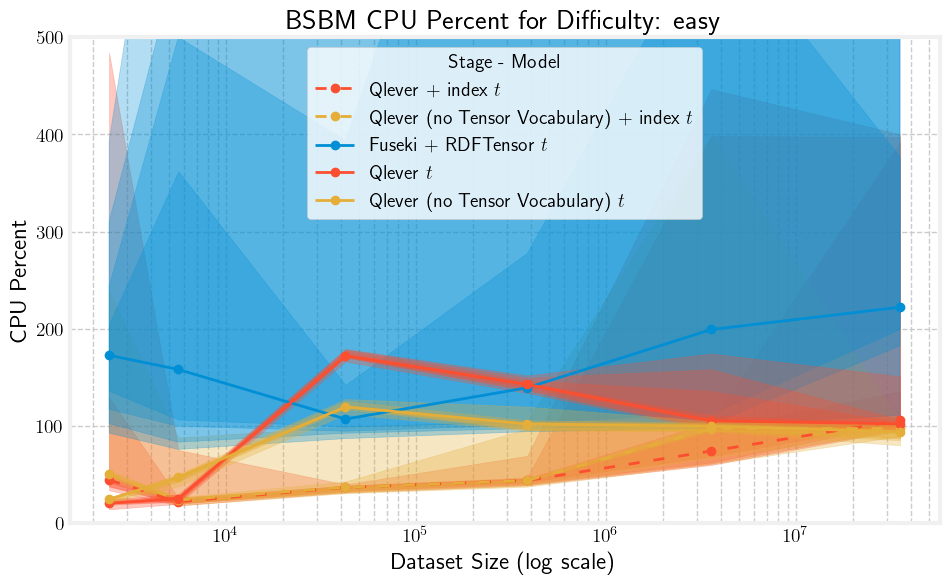

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


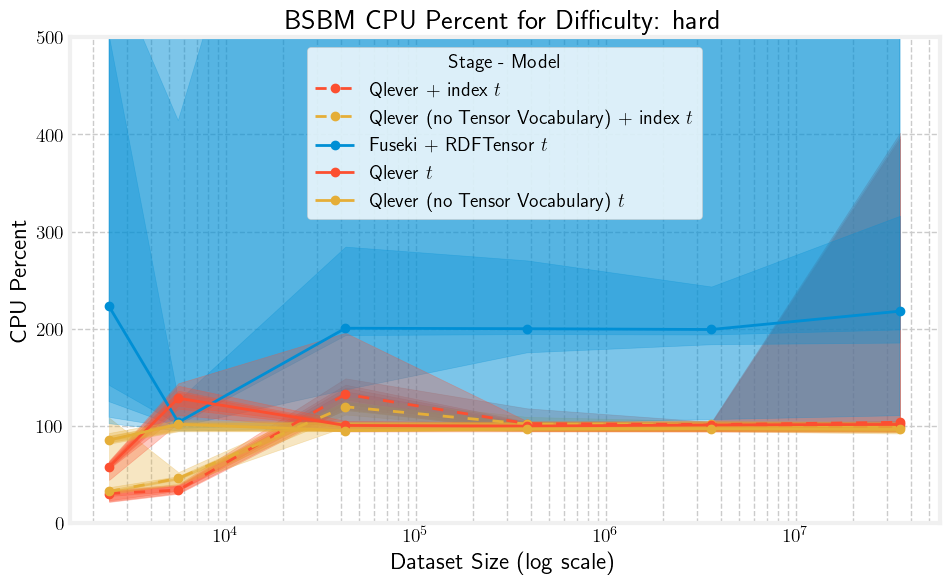

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


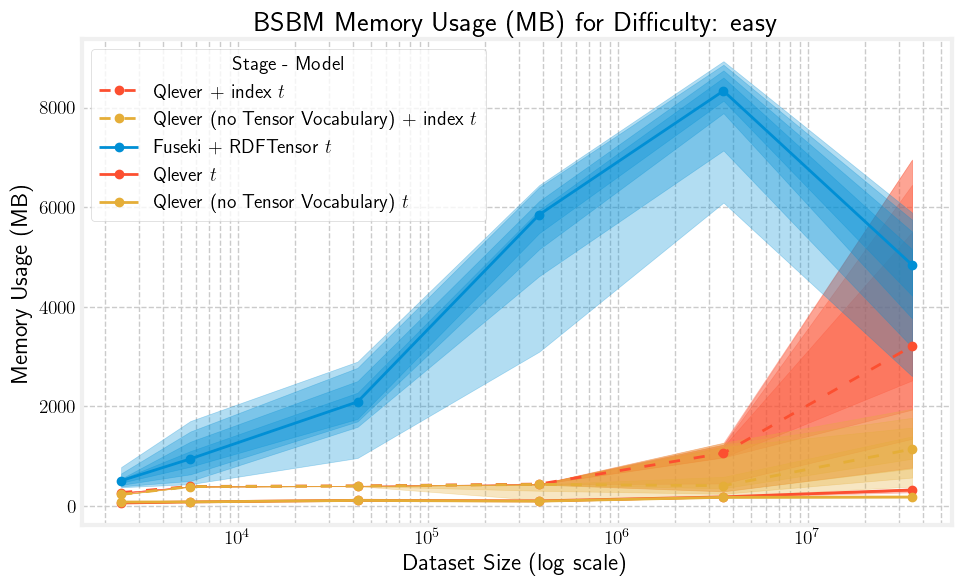

Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]


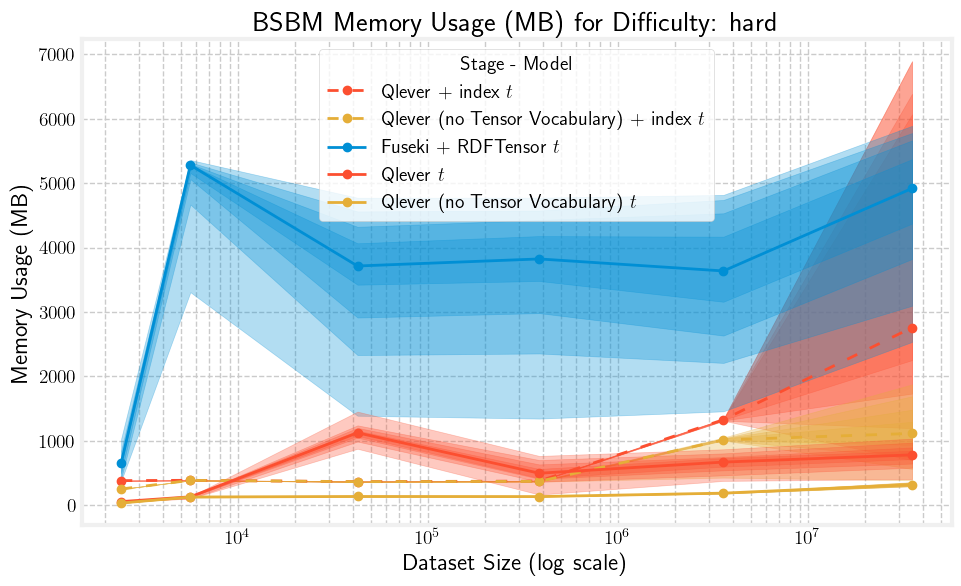

In [43]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_stats_map = {
    "cpu_percent": "CPU Percent",
    "mem_usage_mb": "Memory Usage (MB)",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_stats_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            stats_df,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
            fill_pdf=True,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Dataset Size (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        if relevant_measure == "cpu_percent":
            ax.set_ylim(0, 500)
            ax.legend()
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()


Quantiles [0.05, 0.95]


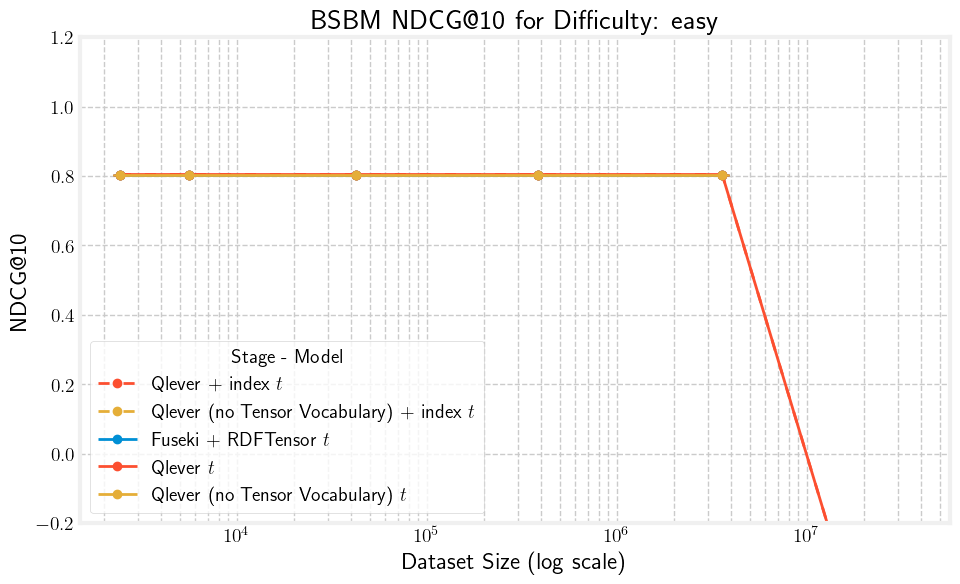

Quantiles [0.05, 0.95]


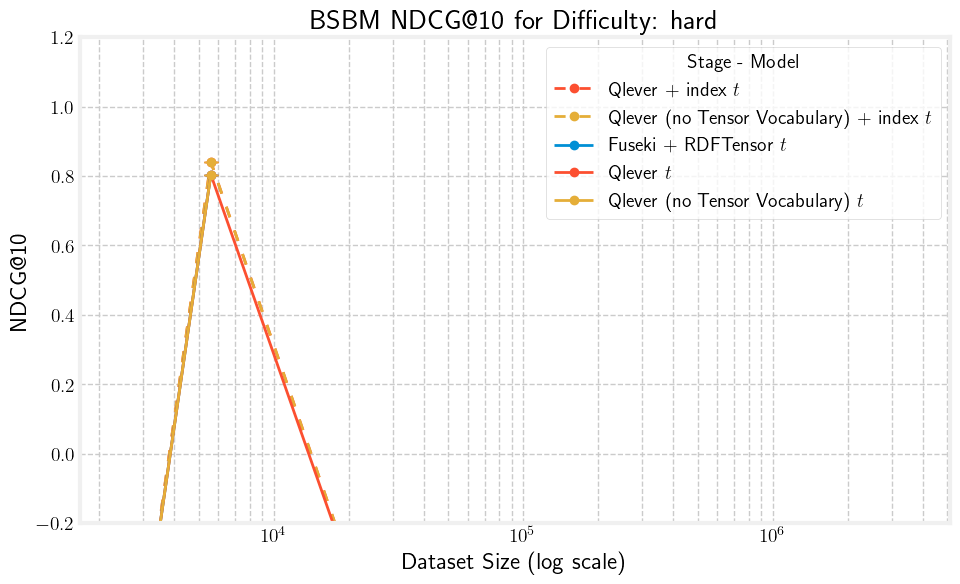

Quantiles [0.05, 0.95]


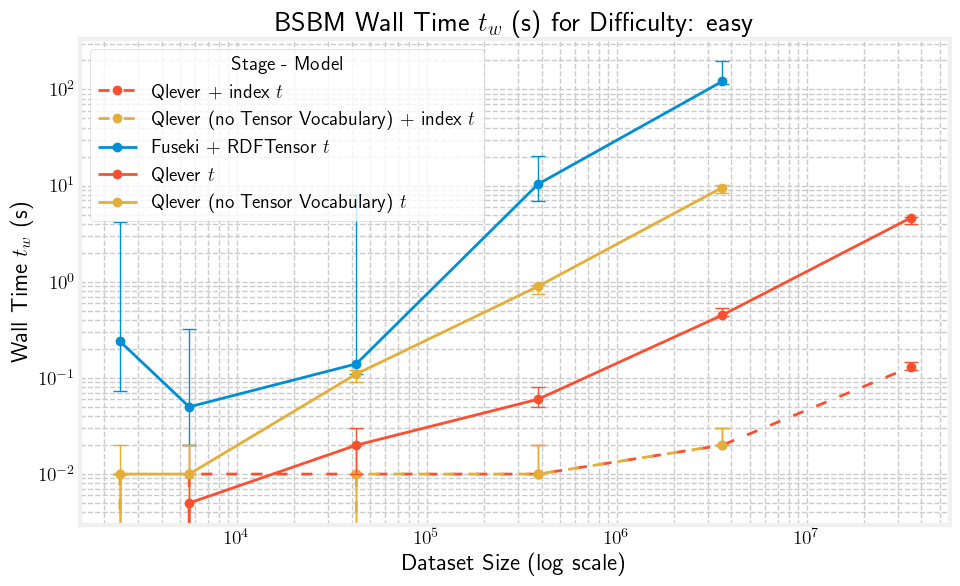

Quantiles [0.05, 0.95]


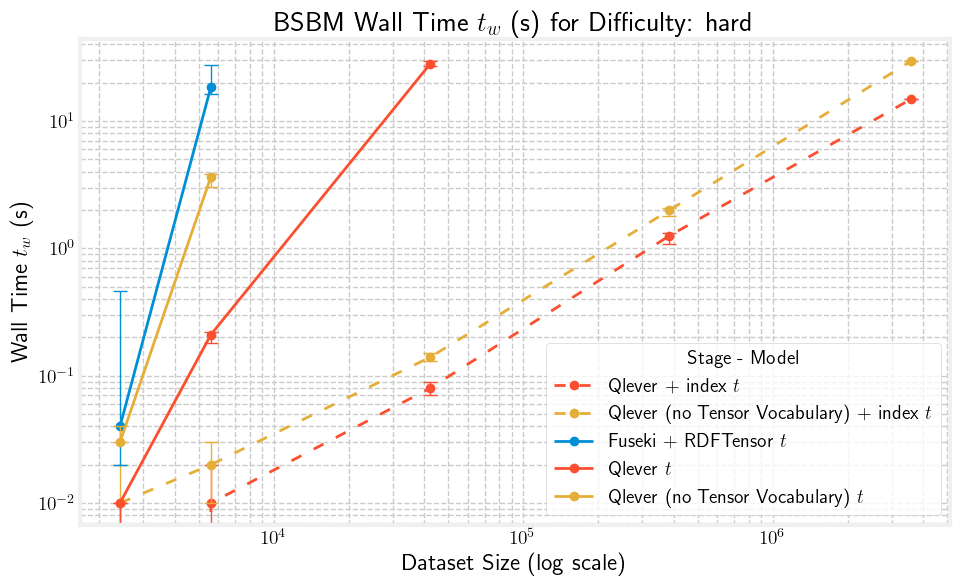

In [44]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_measure_map = {
    "ndcg_score": "NDCG@10",
    "wall_time": "Wall Time $t_w$ (s)",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_measure_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            timings_df,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
            fill_pdf=False,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Dataset Size (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        if relevant_measure == "wall_time":
            ax.set_yscale("log")
        elif relevant_measure == "ndcg_score":
            ax.set_ylim(-0.2, 1.2)
        ax.legend()
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1\\textwidth",
            axis_width="2\\textwidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()
